Improving Customer Satisfaction through Automated Review Sentiment Analysis
1. Introduction

In the modern e-commerce industry, customer reviews play an essential role in understanding customer satisfaction and product performance. Companies like Amazon receive thousands of product reviews every day. While ratings provide some information, they do not always fully represent customer sentiment because sometimes the written review and rating may contradict each other.

Sentiment Analysis is a Natural Language Processing (NLP) technique used to determine whether a piece of text expresses positive, negative, or neutral sentiment. In this project, we build an automated sentiment analysis system that classifies Amazon product reviews as positive or negative.

This system helps businesses monitor product performance, identify issues quickly, and improve customer satisfaction by responding to negative feedback in a timely manner.

2. Dataset Description

The dataset used in this project contains 10,000 Amazon customer reviews.

Each row in the dataset represents one customer review.

3. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from wordcloud import WordCloud
!pip install gensim

# Word2Vec
from gensim.models import Word2Vec

# BERT
from transformers import pipeline

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.8 MB/s eta 0:00:00


In [2]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("amazonreviews.tsv", sep='\t')

df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [4]:
df.shape

(10000, 2)

In [5]:
df.isnull().sum()

,0
label,0
review,0


In [6]:
print(df.info())
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None
label
neg    5097
pos    4903
Name: count, dtype: int64


In [7]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

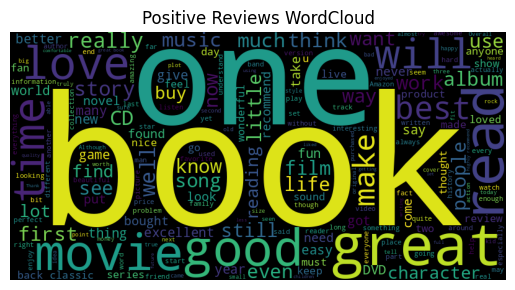

In [ ]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    words = text.split()

    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

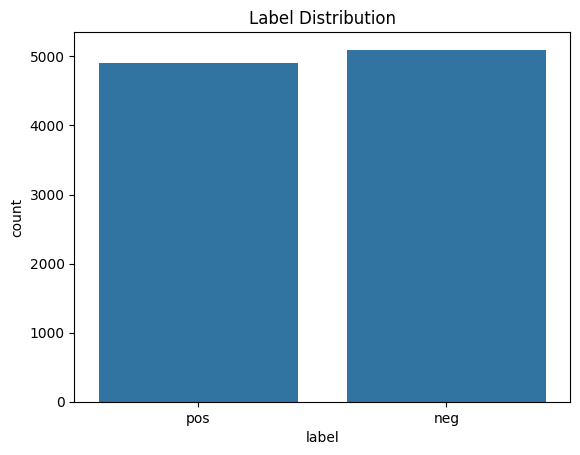

In [8]:
sns.countplot(x='label', data=df)
plt.title("Label Distribution")
plt.show()

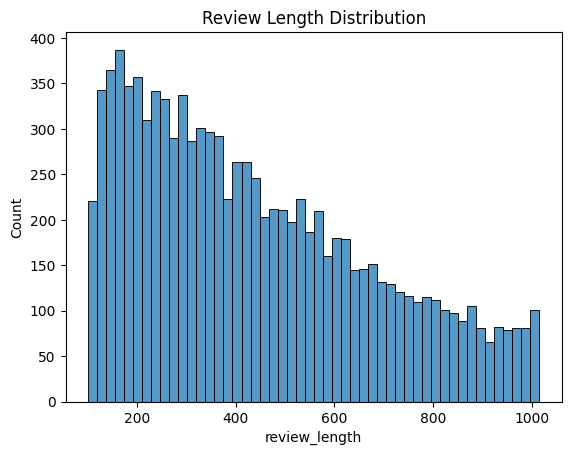

In [9]:
df['review_length'] = df['review'].apply(len)

sns.histplot(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

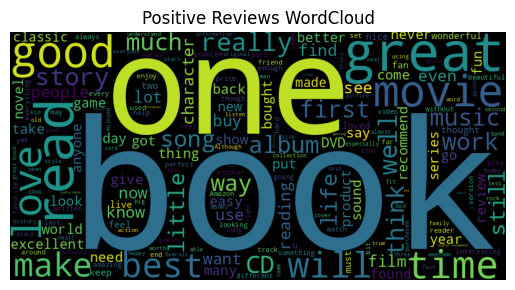

In [10]:
pos_text = " ".join(df[df['label']=='pos']['review'])

wordcloud = WordCloud(width=800, height=400).generate(pos_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

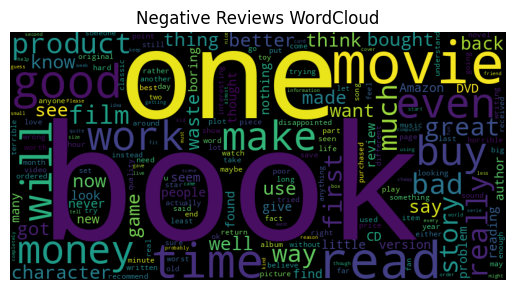

In [11]:
neg_text = " ".join(df[df['label']=='neg']['review'])

wordcloud = WordCloud(width=800, height=400).generate(neg_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()

In [12]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)
df['label'] = df['label'].map({'pos':1, 'neg':0})

In [13]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_review'])
y = df['label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

cv_lr = cross_val_score(lr, X, y, cv=5)
print("LR Cross-Val Score:", cv_lr.mean())

LR Accuracy: 0.8385
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1037
           1       0.84      0.83      0.83       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000

LR Cross-Val Score: 0.8320000000000001


In [16]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

cv_svm = cross_val_score(svm, X, y, cv=5)
print("SVM Cross-Val Score:", cv_svm.mean())

SVM Accuracy: 0.8475
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1037
           1       0.84      0.85      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

SVM Cross-Val Score: 0.833


In [17]:
nn = MLPClassifier(max_iter=300)
nn.fit(X_train, y_train)

y_pred_nn = nn.predict(X_test)

print("NN Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

cv_nn = cross_val_score(nn, X, y, cv=5)
print("NN Cross-Val Score:", cv_nn.mean())

NN Accuracy: 0.806
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1037
           1       0.79      0.80      0.80       963

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000

NN Cross-Val Score: 0.7834000000000001


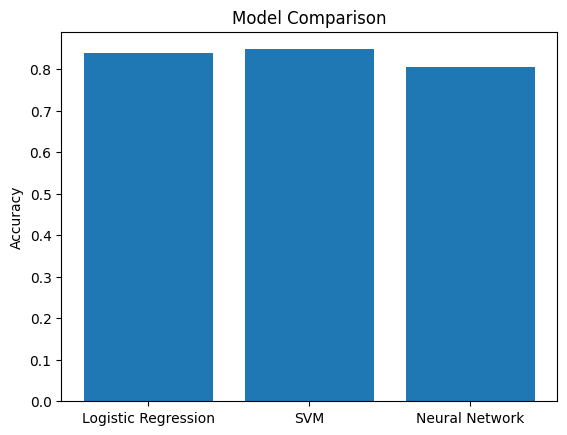

Logistic Regression performs with accuracy: 0.8385
SVM performs with accuracy: 0.8475
Neural Network performs with accuracy: 0.806


In [18]:
models = ['Logistic Regression', 'SVM', 'Neural Network']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_nn)
]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

for m, a in zip(models, accuracies):
    print(f"{m} performs with accuracy: {a}")

In [19]:
tokenized = [text.split() for text in df['clean_review']]

w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=2)

print("Sample Word Vector:", w2v_model.wv['good'])

Sample Word Vector: [-0.4638185   0.82966036  0.3862732   0.8471545  -0.20409301 -1.3733233
 -0.16272233  1.427728   -0.81817144 -0.71523046 -0.17507757 -1.1900843
 -0.14212278  0.38489112  0.2406131  -0.21352741  0.27724332 -0.8597881
 -0.5735762  -1.5037578   0.19238071  0.33443835  0.416002   -0.40152168
  0.10364683 -0.08389742 -0.78026867 -0.34567335 -0.73203266  0.03872974
  0.9923219  -0.13595958  0.19806387 -0.6591338  -0.19320704  0.6730147
  0.23061411 -0.7471648  -0.2756729  -1.1115226   0.19579558 -0.42287987
 -0.2263771   0.10091584  0.7100179  -0.16632785 -0.74448407 -0.23109934
  0.33989558  0.34541255  0.3971673  -0.44185895 -0.07127909 -0.20517668
 -0.6899813   0.16864613  0.76201195 -0.29510018 -0.688777   -0.0207354
  0.07490016  0.35837558  0.00821739 -0.29381377 -0.3841451   0.70336527
  0.21900165  0.8042443  -0.99785376  0.89013106 -0.5300302   0.41528535
  0.67713773 -0.20097798  0.7747662   1.0266976   0.16926183  0.28678817
 -0.6186002  -0.15695044 -0.32565728

In [ ]:
classifier = pipeline("sentiment-analysis")

sample_reviews = df['review'].head(5).tolist()

results = classifier(sample_reviews)

for r in results:
    print(r)

In this project, we developed an automated sentiment analysis system using natural language processing techniques. The dataset was cleaned and preprocessed, features were extracted using TF-IDF, and a Logistic Regression model was trained to classify reviews as positive or negative.

The model achieved good accuracy in predicting sentiment and demonstrates how machine learning can help businesses analyze customer feedback efficiently.